# RAG with Ollama and Chroma

In [35]:
import ollama
from langchain_chroma import Chroma
from langchain_classic.chains.question_answering.map_reduce_prompt import messages
from langchain_core.documents import Document
from langchain_community.document_loaders.pdf import PyPDFDirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import OllamaEmbeddings
from sqlalchemy.sql.annotation import Annotated

I loaded the PDF documents from the `./data` directory.

In [37]:
document_loader = PyPDFDirectoryLoader('./data')
documents = document_loader.load()
print(f'Loaded {len(documents)} documents')

Loaded 1149 documents


Since the documents can be long, I split them into smaller chunks of 1000 characters with an overlap of 100 characters. I also added a unique ID to each chunk based on the source document and page number. It was important because I wanted to avoid adding duplicate chunks to the vector database.

In [38]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks = text_splitter.split_documents(documents)

last_page_id = None
current_chunk_index = 0
for chunk in chunks:
    source = chunk.metadata.get('source', 'unknown')
    page = chunk.metadata.get('page', 'number')
    current_page_id = f'{source}:{page}'
    if current_page_id == last_page_id:
        current_chunk_index += 1
    else:
        current_chunk_index = 0
    last_page_id = current_page_id
    chunk_id = f'{current_page_id}:{current_chunk_index}'
    chunk.metadata['id'] = chunk_id

#print(chunks[15])

page_content='as possible. This process assures the 
maximum transfer of both the words and 
the thoughts contained in the original.
The CSB uses optimal equivalence 
as its translation philosophy . In the 
many places throughout the Bible 
where a word-for-word rendering is 
understandable, a literal translation is 
used. When a word-for-word rendering 
might obscure the meaning for a modern 
audience, a more dynamic translation 
is used. The CSB places equal value on 
fidelity to the original and readability 
for a modern audience, resulting in a 
translation that achieves both goals.
The Gender Language Usage in Bible 
Translation
The goal of the translators of the CSB has 
not been to promote a cultural ideology but 
to translate the Bible faithfully . Recognizing 
modern usage of En glish, the CSB regular -
ly translates the plural of the Greek word 
ανθρωπος (“man”) as “people” instead of 
“men,” and occasionally the singular as “one,” 
“someone,” or “everyone,” when the supporti

Creating the vector database with Ollama embeddings and Chroma DB. I used the `nomic-embed-text` model for generating the embeddings, but you can choose any other model that suits your needs. I also set the persist directory to `./data/database`.

In [39]:
embedding_model = OllamaEmbeddings(model='nomic-embed-text')
db = Chroma(collection_name='rag_datas', persist_directory='./data/database', embedding_function=embedding_model)

Check if there are already some items in the database and only add the new chunks that are not already present. This way I avoid adding duplicate chunks to the database and keep it clean.
It was more than 6000 chunks, so I added them in two batches of 3000 chunks each to avoid any potential issues with adding too many documents at once (limit was around 5500).

In [44]:
existing_items = db.get(include=[])
existing_ids = set(existing_items['ids'])
new_chunks = [chunk for chunk in chunks if chunk.metadata['id'] not in existing_ids]
new_ids = [chunk.metadata['id'] for chunk in new_chunks]
if len(new_ids) > 0:
    db.add_documents(documents=new_chunks[:3000], ids=new_ids[:3000])
    db.add_documents(documents=new_chunks[3000:], ids=new_ids[3000:])

Testing the working RAG.

In [50]:
bang_question = "How many player can play Bang?"
db_retriever = db.as_retriever(search_kwargs={'k': 3})
db_answer = db_retriever.invoke(question)
print(dbanswer[1].page_content)

2
PREPARATION
(Before the first game remove carefully the bullet tokens from their frames.)
Each player takes a playing board (place it in front of you to hold your role, 
your character, your weapon and your bullets).
Take as many role cards as the number of players, divided as follows:
 4 players: 1 Sheriff, 1 Renegade, 2 Outlaws
 5 players: 1 Sheriff, 1 Renegade, 2 Outlaws, 1 Deputy
 6 players: 1 Sheriff, 1 Renegade, 3 Outlaws, 1 Deputy
 7 players: 1 Sheriff, 1 Renegade, 3 Outlaws, 2 Deputy
Shuffle the cards and give one, face down, to each player. The Sheriff 
reveals himself by turning his card face up. All other players look at their 
role but keep it secret.
Shuffle the characters and give one face up to each player. 
Each player now announces the name of his character and 
reads his ability. Each player takes as many bullets as 
shown on his character.
The Sheriff plays the game with one additional bullet: if 
his character card shows three bullets, he is considered


# State Graph for RAG Chatbot

In [144]:
from langgraph.graph import StateGraph, START, END, add_messages
from typing import TypedDict, Annotated
from langchain_ollama import ChatOllama
from ddgs import DDGS
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from datetime import datetime
from langgraph.checkpoint.memory import MemorySaver

Initialize the Ollama LLM and the memory saver for the chatbot state. The chatbot state is defined as a TypedDict with a list of messages.

In [145]:
llm = ChatOllama(model='minimax-m2.5:cloud', validate_model_on_init=True)

memory = MemorySaver()

class ChatbotState(TypedDict):
    messages: Annotated[list, add_messages]

It is an LLM tool that can access the internet through DuckDuckGo text search for any information. It takes a query string and a maximum number of results to return, and it returns a list of documents that might contain the relevant information for the query.

In [146]:
@tool
def web_search_tool(query: str, max_results: int) -> list:
    """
    This tool can access to the internet through DuckDuckGo text search for any information.
    :param query: string to search on the internet
    :param max_results: how many results to return
    :return: list of documents that might contain the relevant information for the query
    """
    return list(DDGS().text(query, max_results=max_results))

A RAG tool that can access to the vector database to find and retrieve relevant information for a statement.

In [147]:
@tool
def rag_node(statement: str, documents: int) -> list[Document]:
    """
    This RAG tool can access to the vector database to find and retrieve relevant information for a statement.
    :param statement: string to find in the vector database
    :param documents: number of documents to return
    :return: list of documents that might contain the relevant information for the statement
    """

    retriever = db.as_retriever(search_kwargs={'k': documents})
    return retriever.invoke(statement)

Just a simple tool to get the date and time. Just to be more example.

In [148]:
@tool
def time_tool() -> str:
    """
    Get the date and time of the execution of the tool.
    :return: string with the date and time of the execution of the tool
    """
    return str(datetime.now())

Collect tools in a list and bind them to the LLM. This way the LLM can decide which tool to use based on the user's question and the context of the conversation. The tools will be available for the LLM to invoke when needed.

In [149]:
tools = [web_search_tool, time_tool, rag_node]

llm_with_tools = llm.bind_tools(tools)

Chatbot node initialized, it invokes the LLM.

In [150]:
def chatbot_node(state: ChatbotState) ->  ChatbotState:
    return {'messages': [llm_with_tools.invoke( state['messages'] ) ] }

Create the state graph for the chatbot. The graph has two nodes: the chatbot node and the tools node. The chatbot node is the main node that handles the conversation with the user, while the tools node is a conditional node that checks if any of the tools need to be invoked based on the user's question and the context of the conversation. The edges between the nodes define the flow of the conversation and how the chatbot can use the tools when needed.

In [160]:
graph = StateGraph(ChatbotState)

graph.add_node('chatbot', chatbot_node)
graph.add_node('tools', ToolNode(tools))

graph.add_edge(START, 'chatbot')
graph.add_conditional_edges('chatbot', tools_condition)
graph.add_edge('tools', 'chatbot')
graph.add_edge('chatbot', END)

app = graph.compile(checkpointer=memory)

Only for visualization purposes. It is not necesary.

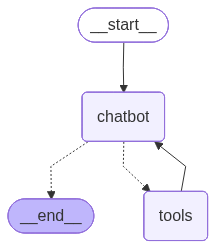

In [154]:
from IPython.display import display, Image

display(Image(app.get_graph().draw_mermaid_png()))

System message.

In [170]:
system_init_message = """
You are a very helpful assistant. Use firstly retrieval and secondly web search tools to find the information needed to answer the user's question. Always try to use the retrieval tool first if you need context, then other tools if you still don't know the answer to the user's question. Answer as short as possible, but be informative enough!
"""

A simple loop to interact with the chatbot. The user can enter a thread ID to start a new conversation or continue an existing one. The chatbot will respond to the user's messages and use the tools when needed to find the relevant information for the user's questions. The conversation will continue until the user decides to exit by typing 'exit', 'quit', or 'esc'. The chatbot state is saved in the memory saver, so it can be retrieved later using the same thread ID.

In [169]:
thread_id = input("Enter thread ID: ")
config = {'configurable': {'thread_id': thread_id} }

if memory.get(config) is None:
    state: ChatbotState = {'messages': [{'role': 'system', 'content': system_init_message}]}
    state = app.invoke(state, config=config)

while True:
    in_message = input("User: ")
    if in_message.lower().strip() in ['exit', 'quit', 'esc']:
        break

    print(f"User: {in_message}")
    state: ChatbotState = {'messages': [
        {'role': 'user', 'content': in_message}
    ]}

    state = app.invoke(state, config=config)
    response = state['messages'][-1].content
    print(f"Bot: {response}")

User: who is vulture sam in bang board game?
Bot: **Vulture Sam** is a character in the board/card game **BANG!**

**Ability:** When any other character is eliminated (dies) from the game, Vulture Sam takes all the cards that player had in their hand and in play (in front of them), and adds them to their own hand.

**Stats:** 4 life points (health)

**Strategy:** Vulture Sam needs other players to be eliminated to benefit from their cards. The best strategy is to outlive opponents rather than eliminate them yourself - you want others to kill each other off so you can collect their cards. This makes Vulture Sam a formidable character in the late game when multiple players have been eliminated.

**Note:** Vulture Sam does NOT draw the Dynamite card when eliminating a player (the Dynamite is discarded if it explodes).


If you want to delete a thread from the memory.

In [174]:
memory.delete_thread('1')

# Technical Choices and Justifications
- Vector Database: ChromaDB
I chose ChromaDB for the retrieval component because it is exceptionally memory-friendly and straightforward to run locally. It is entirely open-source (free) and offers seamless integration with Python, particularly within the LangChain ecosystem, making it the perfect choice for a lightweight, scalable RAG prototype.

- LLM Framework: Ollama
To manage and serve the models, I utilized Ollama. While it requires a separate installation, it is an invaluable, free tool that provides access to a wide variety of high-quality models. Its ecosystem makes it incredibly easy to compare, pull, and swap different models during the development and testing phases.

- Embedding Model: nomic-embed-text
For document vectorization, I selected the nomic-embed-text model. It is a highly popular choice with a large user base. It offers an impressive context window while maintaining a very small storage footprint, which allows for fast and efficient local execution without overloading system resources.

- Core LLM: minimax-m2.5:cloud
Although my initial intention was to run the entire pipeline strictly locally, hardware constraints necessitated a pragmatic adjustment. I experimented with several ultra-small local models (around 0.6B parameters), but their inference speed and logical reasoning capabilities were insufficient for a complex agentic workflow. I chose minimax-m2.5:cloud because benchmarks highlight its excellent performance, and during my testing, it provided high-quality, reliable responses. Using this cloud endpoint for the prototype drastically improved execution speed and ensured the tool-calling logic functioned smoothly.

- Pipeline Architecture: LangGraph Tool-Calling Agent
To fully satisfy the assignment's requirement for "agentic behavior," I intentionally designed a pipeline capable of utilizing multiple tools (RAG, Web Search, System Time). Instead of a static, linear workflow, this LangGraph setup—utilizing an LLM bound with tools and conditional edges—enables true autonomous decision-making. The agent dynamically analyzes the user's intent and independently decides which specific tool to invoke to solve the sub-task at hand.

# Bottlenecks
- Hardware Dependency of Local Components: While the vector database (ChromaDB) and the embedding model (nomic-embed-text) are lightweight, they execute locally. Consequently, the speed of the ingestion pipeline (calculating embeddings for thousands of chunks) and the latency of vector retrieval are heavily bottlenecked by the host machine's CPU and available RAM.

- Internet Dependency & Web Search Limitations: The system relies on an active internet connection both for the cloud-based LLM endpoint (minimax-m2.5:cloud) and the DuckDuckGo web search tool. This dual dependency means the application is not offline-capable and is subject to network latency, which can significantly slow down response times. Furthermore, the DuckDuckGo search tool might retrieve irrelevant, noisy, or SEO-manipulated data. If the search results lack precision, the LLM might mistakenly incorporate this irrelevant context into its final answer, degrading the overall accuracy of the agent.

- LLM Hallucinations & Reasoning Limits: Although the chosen model performs exceptionally well for a prototype, it is not a massive frontier enterprise model (like Google's Gemini or OpenAI's GPT-4). Therefore, it remains susceptible to occasional hallucinations and might struggle with highly complex multi-step reasoning, especially if the retrieved context is dense or contradictory.

- Embedding Model Constraints: The local nomic-embed-text model is efficient, but its smaller parameter size and dimensional space mean it cannot capture semantic nuances as perfectly as massive, commercial embedding models. This might result in slightly lower retrieval accuracy when dealing with highly specialized or ambiguous vocabulary.